In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
from tqdm import tqdm
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import balanced_accuracy_score
import anndata as ad
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

load_dotenv()

FIGURE_DIR = Path("../../book/book/images")
datadir = Path(os.getenv('DATADIR')) / 'immune_aging'

rng = np.random.default_rng(1234)

### Negative controls

In [3]:
datafile = datadir / 'wf_snakemake/checkpoints/dataset-OneK1K_step-07_desc-pseudobulk.h5ad'

adata = ad.read_h5ad(datafile)
adata

AnnData object with n_obs × n_vars = 4635 × 29515
    obs: 'cell_type', 'donor_id', 'n_cells', 'development_stage', 'sex', 'age', 'total_counts'

In [4]:
# filter by cell type
cell_type = 'central memory CD4-positive, alpha-beta T cell'
adata_ct = adata[adata.obs['cell_type'] == cell_type, :].copy()
adata_df = adata_ct.to_df()

# filter out subjects with low number of cells
n_cells_threshold = 100
sample_sums = adata_ct.obs['n_cells']
adata_df = adata_df.loc[sample_sums[sample_sums >= n_cells_threshold].index, :]
print('excluded samples:', sum(sample_sums < n_cells_threshold))

# filter out genes that are zero in any samples
gene_filter = (adata_df == 0).sum(axis=0) == 0
adata_df = adata_df.loc[:, gene_filter] 
adata_df['age'] = adata_ct.obs.loc[adata_df.index, 'age']
# label under 40 and over 70
adata_df['age_group'] = pd.cut(adata_df['age'], bins=[0, 40, 80, 120], labels=['under_40', '40_to_70', 'over_80'])
# remove age group '40_to_70' to have a clearer contrast
adata_df_full = adata_df.copy()
adata_df = adata_df[adata_df['age_group'] != '40_to_70']
adata_df.age_group.value_counts()

excluded samples: 17


age_group
under_40    112
over_80     111
40_to_70      0
Name: count, dtype: int64

In [12]:
adata_df_full.shape

(910, 4214)

In [5]:
adata_df.to_parquet(datadir / 'control_experiment_central_memory_CD4_T_cells.parquet')

In [6]:
adata_df = pd.read_parquet(datadir / 'control_experiment_central_memory_CD4_T_cells.parquet')
# subsample from each group to have balanced classes
n_per_class = 16
adata_df = pd.concat([
    adata_df[adata_df['age_group'] == 'under_40'].sample(n_per_class, random_state=rng),
    adata_df[adata_df['age_group'] == 'over_80'].sample(n_per_class, random_state=rng)
])

adata_df.shape


(32, 4214)

set up predictive model using a randomly generated disease outcome.

In [7]:


def run_classifier(X, y, model, cv, shuffle_y=False, 
                    scorer=None, rng=None, scale_X=True,
                    nfeatures_to_select=10,
                    bad_feature_selection=False):
    """
    Run a classifier with cross-validation, optionally shuffling the target labels.
    also do scaling and feature selection within each fold
    """
    if shuffle_y:
        if rng is None:
            rng = np.random.default_rng()
        y = rng.permutation(y)

    if scorer is None:
        scorer = balanced_accuracy_score

    if bad_feature_selection:
        # feature selection outside of CV (this is bad practice)
        selector = f_classif
        f_values, p_values = selector(X, y)
        top_k_indices = np.argsort(f_values)[-nfeatures_to_select:]
        X = X[:, top_k_indices]

    results = {}
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if scale_X:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)
 
        if nfeatures_to_select is not None and not bad_feature_selection:
            # feature selection using ANOVA F-test
            selector = f_classif
            f_values, p_values = selector(X_train, y_train)
            # select top 100 features
            top_k_indices = np.argsort(f_values)[-nfeatures_to_select:]

            X_train = X_train[:, top_k_indices]
            X_test = X_test[:, top_k_indices]

       
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_train = model.predict(X_train)

        score_value = scorer(y_test, y_pred)
        train_score_value = scorer(y_train, y_pred_train)
        scorer_name = scorer.__name__.replace('_score', '')
        if f'test_{scorer_name}' not in results:
            results[f'test_{scorer_name}'] = [] 
        results[f'test_{scorer_name}'].append(score_value)
        if f'train_{scorer_name}' not in results:
            results[f'train_{scorer_name}'] = []
        results[f'train_{scorer_name}'].append(train_score_value)

    # compute mean scores across folds
    means = {k: np.mean(v) for k, v in results.items()}
    return means

n_simulations = 5000
results = []
results_bad_fs = []

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.4)

model = SGDClassifier(n_jobs=-1)

over80 = (adata_df['age_group'].values == 'over_80').astype(int)
X = adata_df.drop(columns=['age', 'age_group']).to_numpy()
# do feature selection using VarianceThreshold


y = over80

print('Original data:')
true_result = run_classifier(X, y, model, cv,
        shuffle_y=False, rng=rng)
print(f'Balanced_accuracy: {true_result["test_balanced_accuracy"]:.3f}')
true_result_bad_fs = run_classifier(X, y, model, cv,
        shuffle_y=False, rng=rng,
        bad_feature_selection=True)
print(f'Balanced_accuracy with invalid feature selection: {true_result_bad_fs["test_balanced_accuracy"]:.3f}')

# run simulations with shuffled labels
for i in tqdm(range(n_simulations)):
    proportion_positive = 0.5
    # random binary target
    rng = np.random.default_rng() #i)
    #y = rng.choice([0, 1], size=n_samples, 
    #    p=[1 - proportion_positive, proportion_positive])

    results.append(run_classifier(X, y, model, cv,
        shuffle_y=True, rng=rng))
    results_bad_fs.append(run_classifier(X, y, model, cv,
        shuffle_y=True, rng=rng,
        bad_feature_selection=True))

results_df = pd.DataFrame(results)
results_bad_fs_df = pd.DataFrame(results_bad_fs)


method = 'balanced_accuracy'
print('\nResults using shuffled y labels:')
rand_pval = 1 - np.mean(true_result[f"test_{method}"] > results_df[f'test_{method}'])
print(f'p-value for original data versus shuffled: {rand_pval:.3f}')
print(f'Shuffled {method} with valid feature selection: mean={results_df[f"test_{method}"].mean():.3f}, std={results_df[f"test_{method}"].std():.3f}')
print(f'Shuffled {method} with invalid feature selection: mean={results_bad_fs_df[f"test_{method}"].mean():.3f}, std={results_bad_fs_df[f"test_{method}"].std():.3f}')
print(f'Shuffled training {method}: mean={results_df[f"train_{method}"].mean():.3f}, std={results_df[f"train_{method}"].std():.3f}')

# t-test verus 0.5 for balanced accuracy on shuffled data with and without bad feature selection

from scipy.stats import ttest_1samp
tstat, pval = ttest_1samp(results_df[f'test_{method}'], 0.5)
print(f'T-test versus 0.5 for balanced accuracy on shuffled data with valid feature selection: t={tstat:.3f}, p={pval:.3f}')
tstat, pval = ttest_1samp(results_bad_fs_df[f'test_{method}'], 0.5)
print(f'T-test versus 0.5 for balanced accuracy on shuffled data with bad feature selection: t={tstat:.3f}, p={pval:.3f}')


Original data:
Balanced_accuracy: 0.717
Balanced_accuracy with invalid feature selection: 0.643


100%|██████████| 5000/5000 [01:37<00:00, 51.19it/s]


Results using shuffled y labels:
p-value for original data versus shuffled: 0.006
Shuffled balanced_accuracy with valid feature selection: mean=0.501, std=0.077
Shuffled balanced_accuracy with invalid feature selection: mean=0.613, std=0.118
Shuffled training balanced_accuracy: mean=0.905, std=0.055
T-test versus 0.5 for balanced accuracy on shuffled data with valid feature selection: t=1.312, p=0.190
T-test versus 0.5 for balanced accuracy on shuffled data with bad feature selection: t=67.668, p=0.000


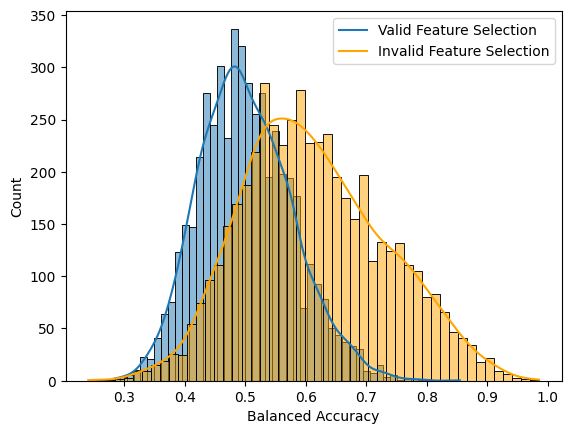

In [ ]:
sns.histplot(results_df[f'test_balanced_accuracy'], bins=50, kde=True)
# overlay bad feature selection
sns.histplot(results_bad_fs_df[f'test_balanced_accuracy'], bins=50, kde=True, color='orange')
plt.xlabel('Balanced Accuracy')
plt.legend(['Valid Feature Selection', 'Invalid Feature Selection'])
plt.savefig(FIGURE_DIR / 'control_experiment_balanced_accuracy_histogram.png', dpi=300)

### positive control example

let's say we want to generate a biomarker based on RNA-seq for a disease that is present in 10% of the population.  We can use the RNA-seq data from the full sample in the earlier study (910 individuals). 

In [ ]:
from dataclasses import dataclass
from typing import Optional


@dataclass
class SignalInjectionConfig:
    """Configuration for signal injection experiments."""
    nfeatures_to_select: int = 1000
    sim_features: int = 10
    n_splits: int = 10
    disease_prevalence: float = 0.1
    noise_sd: float = 1.0
    test_size: float = 0.3
    scale_X: bool = True
    shuffle_y: bool = False


class SignalInjectionClassifier:
    """
    A classifier that supports signal injection for positive control experiments.
    
    This class enables testing classification pipelines by injecting synthetic signals
    into feature data, allowing researchers to validate their analysis approaches
    under known ground truth conditions.
    """
    
    def __init__(
        self,
        config: Optional[SignalInjectionConfig] = None,
        model: Optional[object] = None,
        scorer: Optional[callable] = None,
        rng: Optional[np.random.Generator] = None
    ):
        """
        Initialize the signal injection classifier.
        
        Parameters
        ----------
        config : SignalInjectionConfig, optional
            Configuration object with experiment parameters
        model : sklearn estimator, optional
            Classifier model (defaults to SGDClassifier)
        scorer : callable, optional
            Scoring function (defaults to balanced_accuracy_score)
        rng : np.random.Generator, optional
            Random number generator for reproducibility
        """
        self.config = config if config is not None else SignalInjectionConfig()
        self.model = model if model is not None else SGDClassifier(n_jobs=-1)
        self.scorer = scorer if scorer is not None else balanced_accuracy_score
        self.rng = rng if rng is not None else np.random.default_rng()
        self.cv = StratifiedShuffleSplit(
            n_splits=self.config.n_splits, 
            test_size=self.config.test_size
        )
        
    def _inject_signal(self, X: np.ndarray, y: np.ndarray, beta: float) -> np.ndarray:
        """
        Inject synthetic signal into features to create ground truth relationships.
        
        Parameters
        ----------
        X : np.ndarray
            Feature matrix
        y : np.ndarray
            Target labels (will be replaced)
        beta : float
            Coefficient for simulated features
            
        Returns
        -------
        np.ndarray
            Binary target labels with injected signal
        """
        # Create regressor with signal only in selected features
        X_regressor = np.zeros(X.shape[1])
        X_regressor[:self.config.sim_features] = beta
        np.random.shuffle(X_regressor)
        
        # Generate continuous outcome and add noise
        y_continuous = X @ X_regressor + self.rng.normal(
            0, self.config.noise_sd, size=y.shape
        )
        
        # Binarize based on disease prevalence
        threshold = np.percentile(
            y_continuous, 
            100 * (1 - self.config.disease_prevalence)
        )
        return (y_continuous >= threshold).astype(int)
    
    def _select_features(
        self, 
        X_train: np.ndarray, 
        y_train: np.ndarray, 
        X_test: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        Select top features using ANOVA F-test.
        
        Parameters
        ----------
        X_train : np.ndarray
            Training features
        y_train : np.ndarray
            Training labels
        X_test : np.ndarray
            Test features
            
        Returns
        -------
        tuple[np.ndarray, np.ndarray]
            Selected training and test features
        """
        f_values, _ = f_classif(X_train, y_train)
        top_k_indices = np.argsort(f_values)[-self.config.nfeatures_to_select:]
        return X_train[:, top_k_indices], X_test[:, top_k_indices]
    
    def _scale_features(
        self, 
        X_train: np.ndarray, 
        X_test: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        Scale features using StandardScaler.
        
        Parameters
        ----------
        X_train : np.ndarray
            Training features
        X_test : np.ndarray
            Test features
            
        Returns
        -------
        tuple[np.ndarray, np.ndarray]
            Scaled training and test features
        """
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        return X_train_scaled, X_test_scaled
    
    def _evaluate_fold(
        self, 
        X_train: np.ndarray, 
        X_test: np.ndarray,
        y_train: np.ndarray, 
        y_test: np.ndarray
    ) -> dict:
        """
        Train and evaluate model on a single fold.
        
        Parameters
        ----------
        X_train, X_test : np.ndarray
            Training and test features
        y_train, y_test : np.ndarray
            Training and test labels
            
        Returns
        -------
        dict
            Scores for test and training sets
        """
        self.model.fit(X_train, y_train)
        y_pred = self.model.predict(X_test)
        y_pred_train = self.model.predict(X_train)
        
        scorer_name = self.scorer.__name__.replace('_score', '')
        return {
            f'test_{scorer_name}': self.scorer(y_test, y_pred),
            f'train_{scorer_name}': self.scorer(y_train, y_pred_train),
            'nfeatures': X_train.shape[1]
        }
    
    def run(
        self, 
        X: np.ndarray, 
        y: np.ndarray, 
        beta: Optional[float] = None
    ) -> dict:
        """
        Run cross-validated classification with optional signal injection.
        
        Parameters
        ----------
        X : np.ndarray
            Feature matrix
        y : np.ndarray
            Target labels
        beta : float, optional
            If provided, inject synthetic signal with this coefficient
            
        Returns
        -------
        dict
            Mean scores across all CV folds
        """
        # Convert to numpy arrays
        X = np.array(X)
        y = np.array(y)
        
        # Shuffle or inject signal
        if self.config.shuffle_y:
            y = self.rng.permutation(y)
        elif beta is not None:
            y = self._inject_signal(X, y, beta)
        
        # Collect results across folds
        fold_results = {
            'test_scores': [],
            'train_scores': [],
            'nfeatures': []
        }
        
        for train_idx, test_idx in self.cv.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            # Scale features
            if self.config.scale_X:
                X_train, X_test = self._scale_features(X_train, X_test)
            
            # Select features
            if self.config.nfeatures_to_select is not None:
                X_train, X_test = self._select_features(X_train, y_train, X_test)
            
            # Evaluate fold
            fold_scores = self._evaluate_fold(X_train, X_test, y_train, y_test)
            
            # Store results
            scorer_name = self.scorer.__name__.replace('_score', '')
            fold_results['test_scores'].append(fold_scores[f'test_{scorer_name}'])
            fold_results['train_scores'].append(fold_scores[f'train_{scorer_name}'])
            fold_results['nfeatures'].append(fold_scores['nfeatures'])
        
        # Compute mean scores
        scorer_name = self.scorer.__name__.replace('_score', '')
        return {
            f'test_{scorer_name}': np.mean(fold_results['test_scores']),
            f'train_{scorer_name}': np.mean(fold_results['train_scores']),
            'nfeatures_selected': np.mean(fold_results['nfeatures'])
        }


# Wrapper function for backwards compatibility
def run_signal_injection(X, y, beta=None, model=None, cv=None, shuffle_y=False, 
                    scorer=None, rng=None, scale_X=True,
                    nfeatures_to_select=1000, sim_features=10,
                    n_splits=10, disease_prevalence=0.1, noise_sd=1.0):
    """
    Run a classifier with cross-validation, optionally injecting synthetic signals.
    
    This is a compatibility wrapper around SignalInjectionClassifier.
    For new code, prefer using the class directly.
    """
    config = SignalInjectionConfig(
        nfeatures_to_select=nfeatures_to_select,
        sim_features=sim_features,
        n_splits=n_splits,
        disease_prevalence=disease_prevalence,
        noise_sd=noise_sd,
        scale_X=scale_X,
        shuffle_y=shuffle_y
    )
    
    classifier = SignalInjectionClassifier(
        config=config,
        model=model,
        scorer=scorer,
        rng=rng
    )
    
    return classifier.run(X, y, beta=beta)


In [ ]:
y = adata_df_full['age'].to_numpy()
print(y.shape)
X = adata_df_full.drop(columns=['age', 'age_group']).to_numpy()
print(X.shape)

print('Regression on age with full dataset:')
#run_signal_injection(X, y)

(910,)
(910, 4212)
Regression on age with full dataset:


In [15]:
rng = np.random.default_rng(1234)
n_simulations = 1000
fdr_fsel = 0.1

results = {}
for beta in np.arange(0, 0.0055, 0.0005):
    for nfeatures in [10, 25, 50]:
        print(f'\nDisease classification on synthetic data, beta={beta:.4f}, nfeatures={nfeatures}:')
        n_features = X.shape[1]
        result = []
        for i in range(n_simulations):
            result.append(run_signal_injection(X, y, beta=beta, 
                sim_features=nfeatures))
        results[(beta, nfeatures)] = pd.DataFrame(result)
        results[(beta, nfeatures)]['beta'] = beta
        results[(beta, nfeatures)]['nfeatures'] = nfeatures
        print(f'Balanced_accuracy: mean={results[(beta, nfeatures)]["test_balanced_accuracy"].mean():.3f}, std={results[(beta, nfeatures)]["test_balanced_accuracy"].std():.3f}, nfeatures_selected={results[(beta, nfeatures)]["nfeatures_selected"].mean():.1f}')
results_df = pd.concat(results.values())
results_df.head()

results_df.to_csv(datadir / 'positive_control_beta_nfeatures.csv', index=False)


Disease classification on synthetic data, beta=0.0000, nfeatures=10:
Balanced_accuracy: mean=0.500, std=0.007, nfeatures_selected=1000.0

Disease classification on synthetic data, beta=0.0000, nfeatures=25:
Balanced_accuracy: mean=0.500, std=0.007, nfeatures_selected=1000.0

Disease classification on synthetic data, beta=0.0000, nfeatures=50:
Balanced_accuracy: mean=0.500, std=0.007, nfeatures_selected=1000.0

Disease classification on synthetic data, beta=0.0005, nfeatures=10:
Balanced_accuracy: mean=0.585, std=0.129, nfeatures_selected=1000.0

Disease classification on synthetic data, beta=0.0005, nfeatures=25:
Balanced_accuracy: mean=0.710, std=0.144, nfeatures_selected=1000.0

Disease classification on synthetic data, beta=0.0005, nfeatures=50:
Balanced_accuracy: mean=0.840, std=0.094, nfeatures_selected=1000.0

Disease classification on synthetic data, beta=0.0010, nfeatures=10:
Balanced_accuracy: mean=0.631, std=0.148, nfeatures_selected=1000.0

Disease classification on synthet

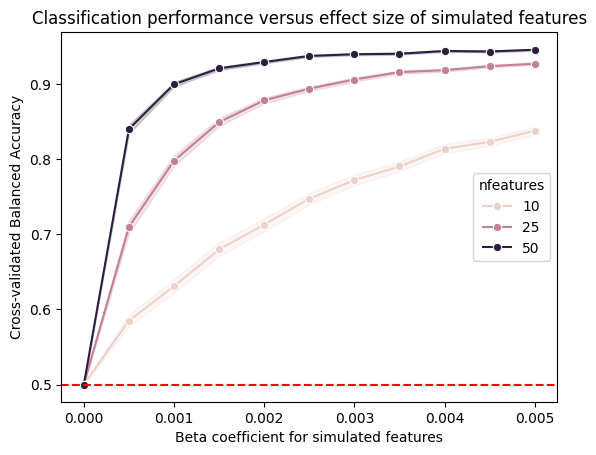

In [23]:
# plot mean R2 versus beta
# first concatenate results
all_results = pd.read_csv(datadir / 'positive_control_beta_nfeatures.csv')

sns.lineplot(data=all_results, x='beta', y='test_balanced_accuracy', hue='nfeatures', 
    marker='o')
plt.xlabel('Beta coefficient for simulated features')
plt.ylabel('Cross-validated Balanced Accuracy')
plt.title('Classification performance versus effect size of simulated features')

plt.axhline(0.5, color='red', linestyle='--')
plt.savefig(FIGURE_DIR / 'control_experiment_classification_balanced_accuracy_vs_beta.png', dpi=300)

assess performance as a function of sample size

In [17]:

nfeatures = 20

results = {}
for beta in np.arange(0, 0.0055, 0.0005):
    for sample_size in [100, 200, 500, adata_df_full.shape[0]]:
        print(f'\nDisease classification on synthetic data, beta={beta:.4f}, sample size={sample_size}:')
        result = []
        # get a set of samples randomly selected from the full dataset
        adata_df_sample = adata_df_full.sample(sample_size, random_state=rng)
        X = adata_df_sample.drop(columns=['age', 'age_group']).to_numpy()
        y = adata_df_sample['age_group'].to_numpy()
    
        for i in range(n_simulations):
            result.append(run_signal_injection(
                X, y, beta=beta, 
                sim_features=nfeatures))
        results[(beta, sample_size)] = pd.DataFrame(result)
        results[(beta, sample_size)]['beta'] = beta
        results[(beta, sample_size)]['sample_size'] = sample_size
        results[(beta, sample_size)]['nfeatures'] = nfeatures

        print(f'Balanced_accuracy: mean={results[(beta, sample_size)]["test_balanced_accuracy"].mean():.3f}, std={results[(beta, sample_size)]["test_balanced_accuracy"].std():.3f}, nfeatures_selected={results[(beta,         
            sample_size)]["nfeatures_selected"].mean():.1f}')

results_df = pd.concat(results.values())
results_df.head()

results_df.to_csv(datadir / 'positive_control_beta_sample_size.csv', index=False)


Disease classification on synthetic data, beta=0.0000, sample size=100:
Balanced_accuracy: mean=0.500, std=0.028, nfeatures_selected=1000.0

Disease classification on synthetic data, beta=0.0000, sample size=200:
Balanced_accuracy: mean=0.500, std=0.017, nfeatures_selected=1000.0

Disease classification on synthetic data, beta=0.0000, sample size=500:
Balanced_accuracy: mean=0.500, std=0.009, nfeatures_selected=1000.0

Disease classification on synthetic data, beta=0.0000, sample size=910:
Balanced_accuracy: mean=0.499, std=0.007, nfeatures_selected=1000.0

Disease classification on synthetic data, beta=0.0005, sample size=100:
Balanced_accuracy: mean=0.659, std=0.144, nfeatures_selected=1000.0

Disease classification on synthetic data, beta=0.0005, sample size=200:
Balanced_accuracy: mean=0.650, std=0.132, nfeatures_selected=1000.0

Disease classification on synthetic data, beta=0.0005, sample size=500:
Balanced_accuracy: mean=0.670, std=0.146, nfeatures_selected=1000.0

Disease clas

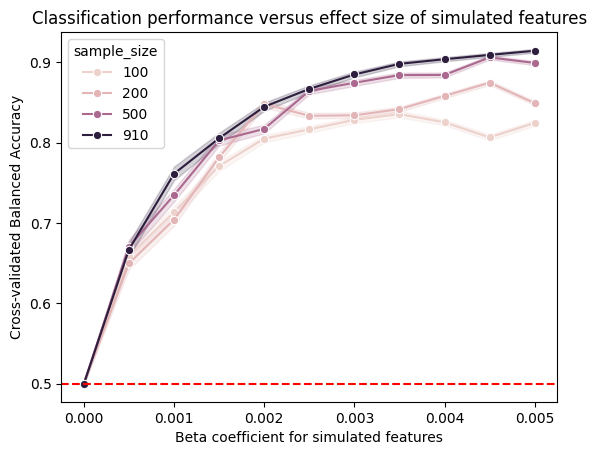

In [24]:
all_results = pd.read_csv(datadir / 'positive_control_beta_sample_size.csv')

sns.lineplot(data=all_results, x='beta', y='test_balanced_accuracy', hue='sample_size', 
    marker='o')
plt.xlabel('Beta coefficient for simulated features')
plt.ylabel('Cross-validated Balanced Accuracy')
plt.title('Classification performance versus effect size of simulated features')

plt.axhline(0.5, color='red', linestyle='--')
plt.savefig(FIGURE_DIR / 'control_experiment_classification_sample_size.png', dpi=300)

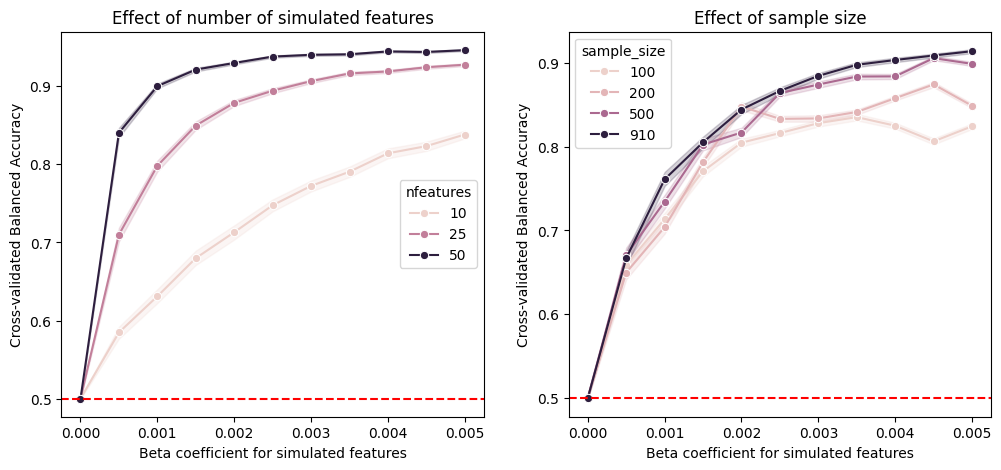

In [179]:
## Combo plot

# left panel
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plt.sca(ax[0])

all_results = pd.read_csv(datadir / 'positive_control_beta_nfeatures.csv')

sns.lineplot(data=all_results, x='beta', y='test_balanced_accuracy', hue='nfeatures', 
    marker='o')
plt.xlabel('Beta coefficient for simulated features')
plt.ylabel('Cross-validated Balanced Accuracy')
plt.title('Effect of number of simulated features')

plt.axhline(0.5, color='red', linestyle='--')

# right panel
plt.sca(ax[1])
all_results = pd.read_csv(datadir / 'positive_control_beta_sample_size.csv')

sns.lineplot(data=all_results, x='beta', y='test_balanced_accuracy', hue='sample_size', 
    marker='o')
plt.xlabel('Beta coefficient for simulated features')
plt.ylabel('Cross-validated Balanced Accuracy')
plt.title('Effect of sample size')

plt.axhline(0.5, color='red', linestyle='--')


plt.savefig(FIGURE_DIR / 'control_experiment_sim_results.png', dpi=300)